In [1]:
import polars as pl
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import statsmodels.api as sm

---
### 1. Carga y Exploración Inicial de los Datos
Para comenzar, cargamos la base de datos `student_productivity.csv` al ambiente de trabajo. Utilizamos los métodos `.info()` y `.describe()` para realizar un análisis exploratorio inicial (EDA). Esto nos permite identificar los **tipos de datos** de cada variable (numéricas vs. categóricas), observar las estadísticas descriptivas básicas, y detectar a simple vista irregularidades como **valores nulos** (missing values) y posibles **valores atípicos** (outliers) en las distribuciones.


In [2]:
df = pd.read_csv(
    "data\student_productivity.csv"
)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5621 non-null   int64  
 1   age                   4973 non-null   float64
 2   gender                5063 non-null   str    
 3   academic_level        4991 non-null   str    
 4   study_hours           5047 non-null   float64
 5   self_study_hours      4954 non-null   float64
 6   online_classes_hours  4939 non-null   float64
 7   social_media_hours    4965 non-null   float64
 8   gaming_hours          4965 non-null   float64
 9   sleep_hours           5068 non-null   float64
 10  screen_time_hours     5035 non-null   float64
 11  exercise_minutes      5022 non-null   str    
 12  caffeine_intake_mg    5021 non-null   float64
 13  part_time_job         4918 non-null   str    
 14  upcoming_deadline     4904 non-null   float64
 15  internet_quality      5098 non-n

In [4]:
df.describe()

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,caffeine_intake_mg,upcoming_deadline,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
count,5621.000000,4973.000000,5047.000000,4954.000000,4939.000000,4965.000000,4965.000000,5068.000000,5035.000000,5021.000000,4904.000000,4946.000000,1518.000000,4988.000000,4905.000000,4983.000000,4912.000000
mean,2811.000000,20.510557,4.538708,2.480454,2.012296,3.002872,1.571458,7.023301,6.979045,250.804820,0.501223,5.516983,0.661397,29.388119,45.633156,37.313526,18.840542
std,1622.787263,2.876399,1.819412,1.178094,0.983104,1.472740,1.112557,1.159948,2.482912,143.685652,0.500049,2.873859,0.473391,9.996024,14.257283,16.841997,12.119456
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,1406.000000,18.000000,3.260000,1.660000,1.320000,2.000000,0.680000,6.250000,5.280000,129.000000,0.000000,3.000000,0.000000,22.460000,35.770000,25.330000,9.410000
50%,2811.000000,20.000000,4.530000,2.480000,2.010000,2.990000,1.500000,7.015000,6.950000,251.000000,1.000000,5.000000,1.000000,29.380000,45.650000,36.920000,17.990000
75%,4216.000000,23.000000,5.760000,3.280000,2.690000,4.030000,2.350000,7.820000,8.705000,375.000000,1.000000,8.000000,1.000000,36.232500,55.410000,49.200000,27.410000
max,5621.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,499.000000,1.000000,10.000000,1.000000,63.480000,97.580000,98.020000,64.090000


---
### 2. Limpieza de Datos: Eliminación de variables no informativas
Al revisar la información del dataset, se hace evidente que la variable `drug_use` contiene una inmensa cantidad de valores nulos (la gran mayoría de la muestra). Dado que carece de suficientes datos reportados para ser estadísticamente significativa en un modelo, se toma la decisión de **eliminar esta columna** completamente (`drop`) para evitar ruido o distorsiones en los análisis posteriores.


In [5]:
df = df.drop(columns=['drug_use'])

---
### 3. Limpieza y Procesamiento de la variable `academic_level`
La variable categórica `academic_level` presentaba dos problemas: espacios en blanco residuales y valores nulos. 
1. Se limpiaron los *strings* (usando `.str.strip()`) para unificar las categorías correctamente.
2. Los valores faltantes se imputaron utilizando la **moda** (el valor más frecuente), lo cual es la técnica estándar y más robusta para mantener la distribución en variables categóricas.
3. Finalmente, se mapearon las categorías a valores numéricos enteros para que puedan ser procesados matemáticamente por los modelos de regresión.


In [6]:
# 1. Verificamos cómo están los datos originalmente
print("Categorías originales:", df['academic_level'].unique())

# 2. Eliminamos los espacios en blanco al inicio y al final del texto
df['academic_level'] = df['academic_level'].str.strip()
print("Categorías sin espacios:", df['academic_level'].unique())

# 3. Rellenamos los valores nulos (nan) con la moda (el nivel más común)

df['academic_level'] = df['academic_level'].fillna(df['academic_level'].mode()[0])
df['academic_level'] = df['academic_level'].map({'High School': 1, 'Undergraduate': 2, 'Postgraduate': 3})

# Comprobamos el resultado final
print("Niveles académicos convertidos a números:", df['academic_level'].unique())

Categorías originales: <ArrowStringArray>
[ 'Undergraduate',    'High School', 'Undergraduate ',   'Postgraduate',
              nan,   'High School ',  'Postgraduate ']
Length: 7, dtype: str
Categorías sin espacios: <ArrowStringArray>
['Undergraduate', 'High School', 'Postgraduate', nan]
Length: 4, dtype: str


Niveles académicos convertidos a números: [2 1 3]


---
### 4. Manejo de Valores Atípicos (Outliers) en `study_hours`
Un análisis visual mediante un *boxplot* nos permitió confirmar la presencia de valores atípicos (outliers) en la variable `study_hours`. 

Para corregir esto sin perder observaciones valiosas (lo cual ocurriría si elimináramos las filas), se aplicó el método estadístico de **Rango Intercuartílico (IQR)** para identificar los bigotes de la distribución. Posteriormente, se utilizó la técnica de **Capping (acotamiento)** usando `.clip()`, imponiendo un límite inferior de cero (para evitar horas negativas) y un límite superior basado en el cálculo de $Q3 + 1.5 * IQR$. Esto asegura que los valores se mantengan dentro de un rango realista sin distorsionar la media.


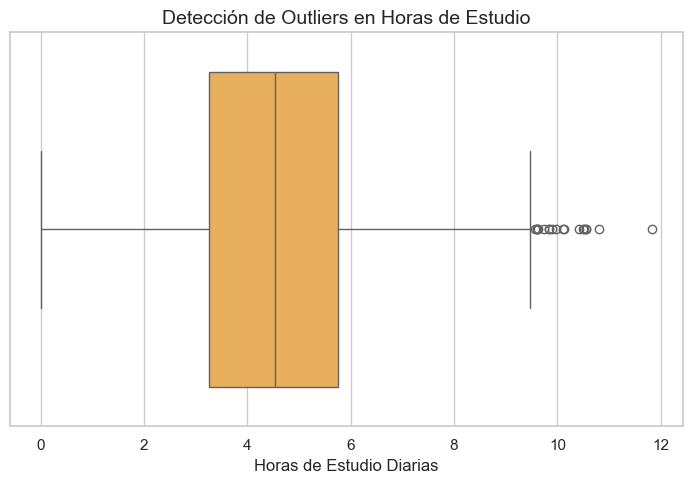

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos
plt.figure(figsize=(14, 5))

# 2. Boxplot (Diagrama de caja)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['study_hours'].dropna(), color='#FFB347')
plt.title('Detección de Outliers en Horas de Estudio', fontsize=14)
plt.xlabel('Horas de Estudio Diarias', fontsize=12)

plt.tight_layout()
plt.show()

In [8]:
# 1. Calcular el Q1 y Q3
Q1 = df['study_hours'].quantile(0.25)
Q3 = df['study_hours'].quantile(0.75)

# 2. Calcular el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# 3. Definir el Límite Superior (y el inferior, asegurando que no baje de 0)
limite_superior = Q3 + 1.5 * IQR
limite_inferior = max(0, Q1 - 1.5 * IQR) 

print(f"El límite superior calculado es: {limite_superior:.2f} horas.")

# 4. Aplicar el Capping usando la función .clip()
df['study_hours'] = df['study_hours'].clip(lower=limite_inferior, upper=limite_superior)

print("¡Outliers topados exitosamente!")

El límite superior calculado es: 9.51 horas.
¡Outliers topados exitosamente!


---
### 5. Generación de Variable Binaria Target (`rindio_examen`)
Las instrucciones indican que un puntaje de `1.0` en `exam_score` señala a un estudiante que no rindió el examen. 
Para preparar nuestra variable dependiente (target) para los modelos de probabilidad lineal, Logit y Probit, creamos la variable binaria `rindio_examen`. Usando lógica vectorizada (`np.where`), asignamos un `1` a todo estudiante con puntaje estrictamente mayor a 1.0 (quienes sí rindieron) y un `0` al resto.


In [9]:
df['rindio_examen'] = np.where(df['exam_score'] > 1.0, 1, 0)

In [10]:
df.reset_index

<bound method DataFrame.reset_index of       student_id   age  gender  academic_level  study_hours  self_study_hours  \
0              1  20.0     NaN               2         5.37              2.09   
1              2  16.0  Female               1         5.85              5.04   
2              3  18.0  Female               2         5.69              2.27   
3              4  24.0    Male               2         2.32              1.06   
4              5  24.0  Female               3         3.87              2.63   
...          ...   ...     ...             ...          ...               ...   
5616        5617  21.0    Male               3         4.16              0.00   
5617        5618  25.0  Female               3          NaN               NaN   
5618        5619   NaN     NaN               3          NaN               NaN   
5619        5620   NaN     NaN               3          NaN               NaN   
5620        5621  18.0    Male               3         3.96           

In [11]:
df.describe()

,student_id,age,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,caffeine_intake_mg,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,rindio_examen
count,5621.000000,4973.000000,5621.000000,5047.000000,4954.000000,4939.000000,4965.000000,4965.000000,5068.000000,5035.000000,5021.000000,4904.000000,4946.000000,4988.000000,4905.000000,4983.000000,4912.000000,5621.000000
mean,2811.000000,20.510557,2.116883,4.536323,2.480454,2.012296,3.002872,1.571458,7.023301,6.979045,250.804820,0.501223,5.516983,29.388119,45.633156,37.313526,18.840542,0.795766
std,1622.787263,2.876399,0.834766,1.812142,1.178094,0.983104,1.472740,1.112557,1.159948,2.482912,143.685652,0.500049,2.873859,9.996024,14.257283,16.841997,12.119456,0.403177
min,1.000000,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1406.000000,18.000000,1.000000,3.260000,1.660000,1.320000,2.000000,0.680000,6.250000,5.280000,129.000000,0.000000,3.000000,22.460000,35.770000,25.330000,9.410000,1.000000
50%,2811.000000,20.000000,2.000000,4.530000,2.480000,2.010000,2.990000,1.500000,7.015000,6.950000,251.000000,1.000000,5.000000,29.380000,45.650000,36.920000,17.990000,1.000000
75%,4216.000000,23.000000,3.000000,5.760000,3.280000,2.690000,4.030000,2.350000,7.820000,8.705000,375.000000,1.000000,8.000000,36.232500,55.410000,49.200000,27.410000,1.000000
max,5621.000000,25.000000,3.000000,9.510000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,499.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000,1.000000


<Axes: >

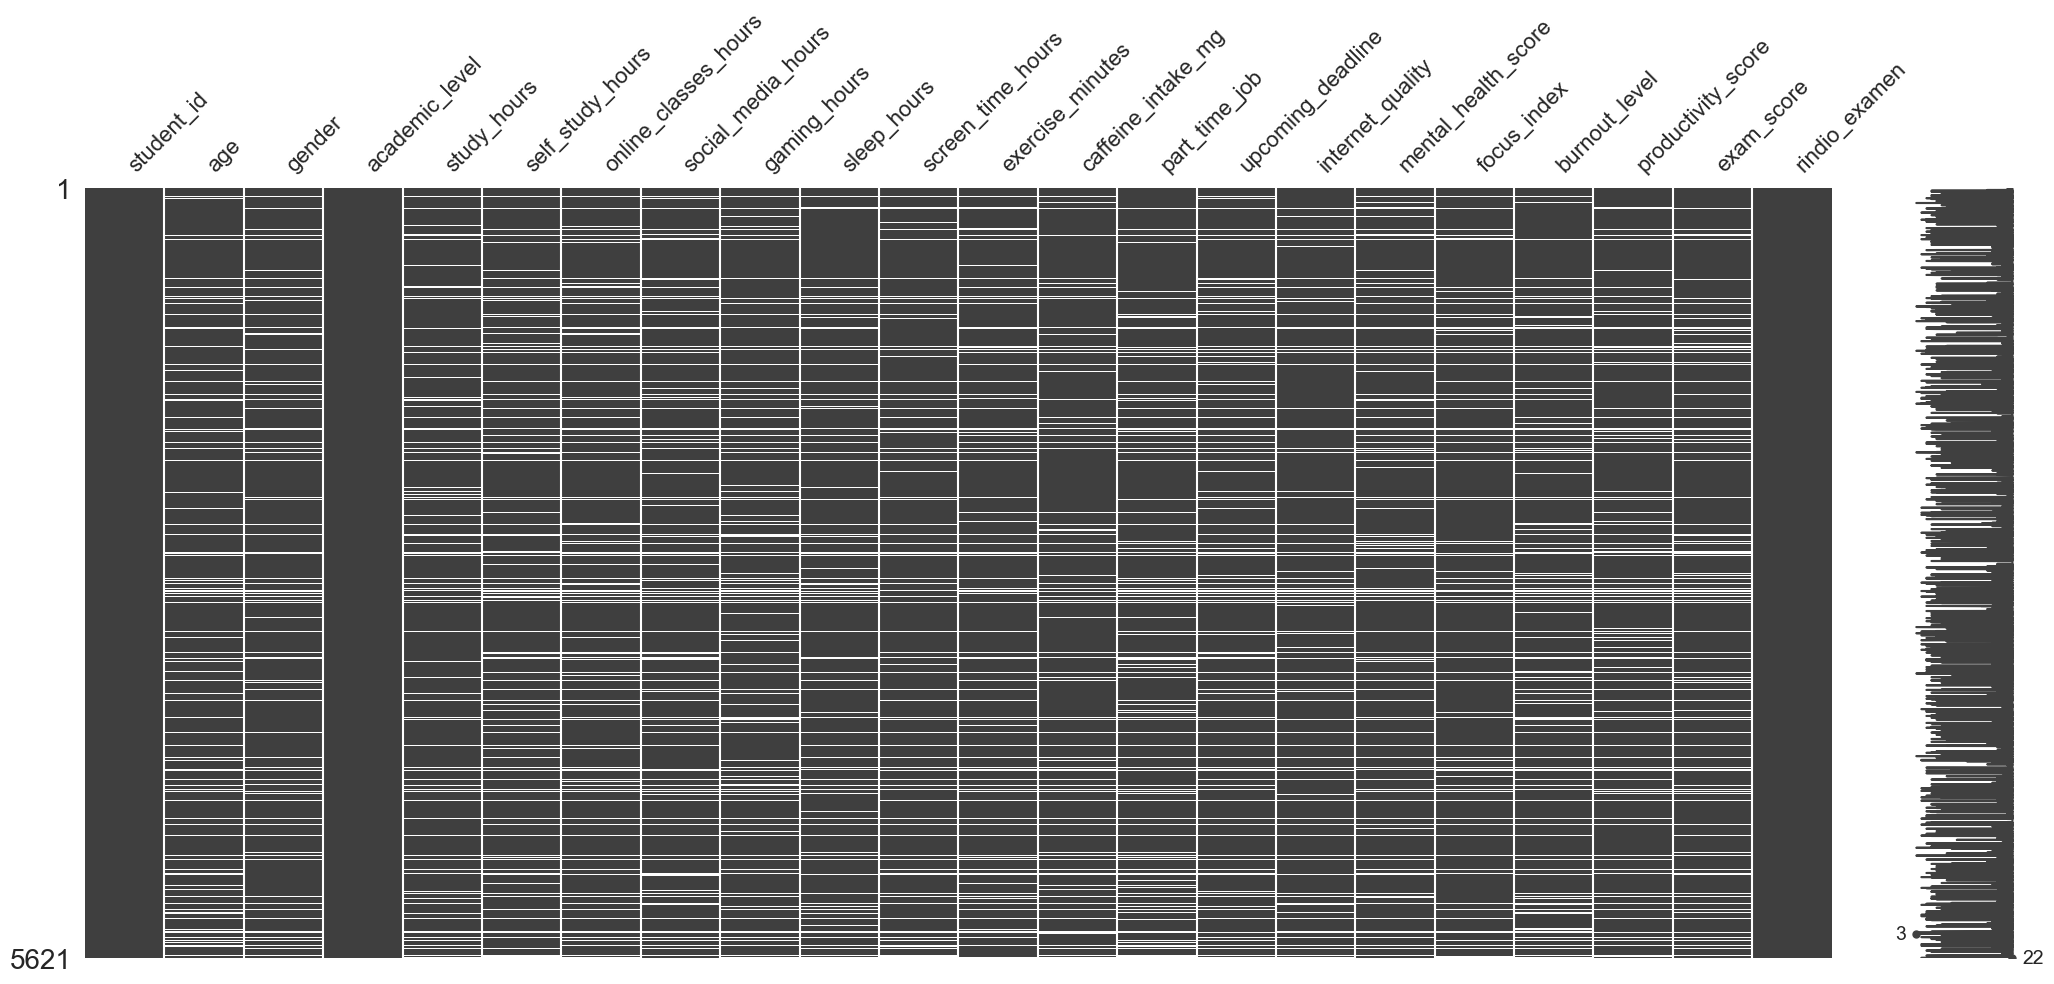

In [12]:
msno.matrix(df)

---
### 7. Imputación de Valores Faltantes en Variables Numéricas
Para evitar la pérdida masiva de información, se ha decidido imputar los datos faltantes en las variables numéricas continuas y discretas. 
Se utilizó la **mediana** (median) en lugar de la media (mean) para variables como la edad, horas de sueño, horas de juego y niveles de estrés. Esta decisión se justifica debido a que la mediana es robusta y no se ve fuertemente afectada por la presencia de valores atípicos extremos (outliers) que suelen existir en métricas de tiempo o productividad.


In [13]:
############# Variables Númericas #############
df['study_hours'] = df['study_hours'].fillna(df['study_hours'].median())
df['self_study_hours'] = df['self_study_hours'].fillna(df['self_study_hours'].median())
df['social_media_hours'] = df['social_media_hours'].fillna(df['social_media_hours'].median())
df['gaming_hours'] = df['gaming_hours'].fillna(df['gaming_hours'].median())
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())
df['screen_time_hours'] = df['screen_time_hours'].fillna(df['screen_time_hours'].median())
df['online_classes_hours'] = df['online_classes_hours'].fillna(df['online_classes_hours'].median())

df['age'] = df['age'].fillna(df['age'].median())
df['caffeine_intake_mg'] = df['caffeine_intake_mg'].fillna(df['caffeine_intake_mg'].median())
df['mental_health_score'] = df['mental_health_score'].fillna(df['mental_health_score'].median())
df['focus_index'] = df['focus_index'].fillna(df['focus_index'].median())
df['burnout_level'] = df['burnout_level'].fillna(df['burnout_level'].median())
df['productivity_score'] = df['productivity_score'].fillna(df['productivity_score'].median())

---
### 8. Estandarización y Codificación de Variables Categóricas
Se procesaron tres variables categóricas clave siguiendo distintos enfoques según su naturaleza:
* **Calidad de Internet (`internet_quality`):** Al ser una variable categórica ordinal (pobre < promedio < buena), estandarizamos el texto eliminando mayúsculas y espacios, imputamos los nulos con la moda, y finalmente la mapeamos a una escala numérica ordinal (1, 2, 3) que preserva su relación de jerarquía.
* **Género (`gender`):** Tras limpiar y rellenar con la moda, aplicamos el método de variables *Dummy* (`pd.get_dummies`) para transformarla a valores numéricos. Se utilizó `drop_first=True` para generar solo la columna `gender_male`, evitando redundancia y previniendo el error estadístico de "multicolinealidad perfecta" crucial para modelos OLS.
* **Examen inminente (`upcoming_deadline`):** Al ya estar expresada de manera binaria, simplemente cubrimos sus valores nulos con la moda.


In [14]:
############# Variables Categóricas #############

#------------ CALIDAD DE INTERNET ------------#
# 1. Transformamos a minúsculas y limpiamos espacios para evitar errores de tipeo
df['internet_quality'] = df['internet_quality'].str.lower().str.strip()
# 2. Rellenamos nulos con la moda
moda_internet = df['internet_quality'].mode()[0]
df['internet_quality'] = df['internet_quality'].fillna(moda_internet)
# 3. Transformación a valores numéricos ORDINALES
df['internet_quality'] = df['internet_quality'].map({'poor': 1, 'average': 2, 'good': 3})
print("Formato final de internet_quality:")
print(df['internet_quality'].value_counts())

#------------ GÉNERO ------------#
# 1. Limpieza de texto
df['gender'] = df['gender'].str.lower().str.strip()

# 2. Rellenar nulos con la moda predominante
moda_genero = df['gender'].mode()[0]
df['gender'] = df['gender'].fillna(moda_genero)

# 3. Transformar a Dummies (Esto creará una nueva columna binaria)
# drop_first=True evita multicolinealidad perfecta (la famosa "trampa dummy") en el OLS
df = pd.get_dummies(df, columns=['gender'], drop_first=True, dtype=int)

# Ahora existirá una columna llamada probablemente 'gender_male' con 1 y 0
print("¡Conversión dummy exitosa! Generada la columna masculina/femenina.")

#------------ EXAMEN PRONTO ------------#
# 1. Rellenamos los nulos con la moda (ya es 0 y 1, por lo que usaremos la clase mayoritaria)
moda_deadline = df['upcoming_deadline'].mode()[0]
df['upcoming_deadline'] = df['upcoming_deadline'].fillna(moda_deadline)

print("Nulos eliminados en upcoming_deadline.")

Formato final de internet_quality:
internet_quality
3    2269
2    1680
1    1672
Name: count, dtype: int64
¡Conversión dummy exitosa! Generada la columna masculina/femenina.
Nulos eliminados en upcoming_deadline.


---
### 9. Binarización de la variable `part_time_job`
Se repitió el proceso de limpieza de texto para unificar las respuestas a simplemente "yes" o "no". Tras asegurar que no hubiese espacios ni mayúsculas que generaran categorías duplicadas, imputamos con la moda y transformamos directamente usando un diccionario manual (`.map()`) a valores binarios matemáticos: 1 para "sí" y 0 para "no", dejándola lista para la regresión.


In [15]:
# 1. Uniformamos texto (convertimos todo a minúsculas y limpiamos espacios)
df['part_time_job'] = df['part_time_job'].str.lower().str.strip()

# Validamos que ahora sólo existan 'yes' o 'no' (o posibles nulos)
print("Categorías extrañas corregidas:", df['part_time_job'].unique())

# 2. Rellenamos datos faltantes (nulos) con la moda (que suele ser 'no')
if df['part_time_job'].isnull().sum() > 0:
    moda_trabajo = df['part_time_job'].mode()[0]
    df['part_time_job'] = df['part_time_job'].fillna(moda_trabajo)

# 3. Transformamos a binario (1 y 0) en la misma columna
df['part_time_job'] = df['part_time_job'].map({'yes': 1, 'no': 0})

print("Formato final de part_time_job:")
print(df['part_time_job'].value_counts())

Categorías extrañas corregidas: <ArrowStringArray>
['no', 'yes', nan]
Length: 3, dtype: str
Formato final de part_time_job:
part_time_job
0    3172
1    2449
Name: count, dtype: int64


---
### 10. Extracción de datos en columnas sucias (`exercise_minutes`)
Se utilizó una **Expresión Regular (Regex)** mediante la función `.str.extract(r'(\d+)')` para "capturar" únicamente los dígitos numéricos dentro del string, parseándolos a formato Flotante (numérico) y luego rellenando los vacíos con la mediana representativa.


In [16]:
# 1. Extraemos SOLO los números de la columna de texto (ignora letras como "mins")
df['exercise_minutes'] = df['exercise_minutes'].astype(str).str.extract(r'(\d+)')

# 2. Lo convertimos a número flotante (float) para poder operarlo matemáticamente
df['exercise_minutes'] = df['exercise_minutes'].astype(float)

# 3. Rellenamos posibles vacíos generados (si alguien escribió "nada") con la mediana
mediana_ejercicio = df['exercise_minutes'].median()
df['exercise_minutes'] = df['exercise_minutes'].fillna(mediana_ejercicio)

print("¡Problema resuelto! exercise_minutes ahora es numérico.")
# Puedes comprobarlo haciendo: print(df['exercise_minutes'].dtype)


¡Problema resuelto! exercise_minutes ahora es numérico.


---
### 11. Control de Calidad y Validación Lógica: Límite de las 24 Horas Diarias
Uno de los problemas lógicos más comunes en encuestas auto-reportadas sobre uso del tiempo, es que las personas pueden exagerar u omitir sumar correctamente, terminando en totales diarios que superan físicamente las 24 horas del día.
Para auditar esto:
1. Calculamos la suma total de horas activas (restando factores que podrían ocurrir simultáneamente pero manteniendo el rubro principal: `study_hours`, `sleep_hours`, `social_media`, `gaming` y `exercise`).
2. Identificamos qué alumnos rompían la regla lógica sumando más de 24 horas.
3. Se aplicó una normalización. Modificamos el valor de dichas horas multiplicándolo por la proporción correcta $(24 / \text{Suma de sus horas})$. De esta forma, castigamos el exceso pero mantenemos de manera realista la "proporción de tiempo" que la persona le dedicó a cada actividad en su día.

In [17]:
# 1. Definimos las columnas base de uso del tiempo (excluyendo las que se solapan)
columnas_horas = [
    'study_hours',
    'sleep_hours', 
    'social_media_hours', 
    'gaming_hours'
]

# (Opcional) Podemos incluir los minutos de ejercicio convirtiéndolos a horas
df['exercise_hours'] = df['exercise_minutes'] / 60.0
columnas_horas.append('exercise_hours')

# 2. Calculamos las horas totales de cada alumno
df['suma_horas'] = df[columnas_horas].sum(axis=1)

# Filtramos para observar cuántos tienen el error lógico
filtro_sobrepasan = df['suma_horas'] > 24.0
print(f"Alumnos que reportaron imposiblemente más de 24 hrs al día: {filtro_sobrepasan.sum()}")

# 3. Solución (Proporción): Escalar las horas para que el máximo sea 24
for col in columnas_horas:
    # Fórmula: Valor nuevo = Valor antiguo * (24 / Suma de sus horas)
    df.loc[filtro_sobrepasan, col] = df.loc[filtro_sobrepasan, col] * (24.0 / df.loc[filtro_sobrepasan, 'suma_horas'])

# Comprobamos el resultado (usamos > 24.01 por los decimales infinitos de Python)
df['suma_horas'] = df[columnas_horas].sum(axis=1)
print(f"Alumnos excedidos tras la limpieza: {(df['suma_horas'] > 24.01).sum()}")

# 4. Limpieza final: eliminamos las columnas temporales (dejamos los minutos originales para no alterar la data madre)
df = df.drop(columns=['suma_horas', 'exercise_hours'])

print("¡Ajuste de 24 horas completado con base proporcional!")


Alumnos que reportaron imposiblemente más de 24 hrs al día: 47
Alumnos excedidos tras la limpieza: 0
¡Ajuste de 24 horas completado con base proporcional!


---
### 12. Verificación de Limpieza Completa
Confirmamos nuevamente que hemos lidiado exitosamente con todas las correcciones necesarias y la eliminación del 100% de los valores faltantes. La gráfica de "Missingno" aparece ahora completamente sólida. La base se encuentra purificada, estandarizada y óptima para el Modelamiento de Regresión No Lineal y MCO


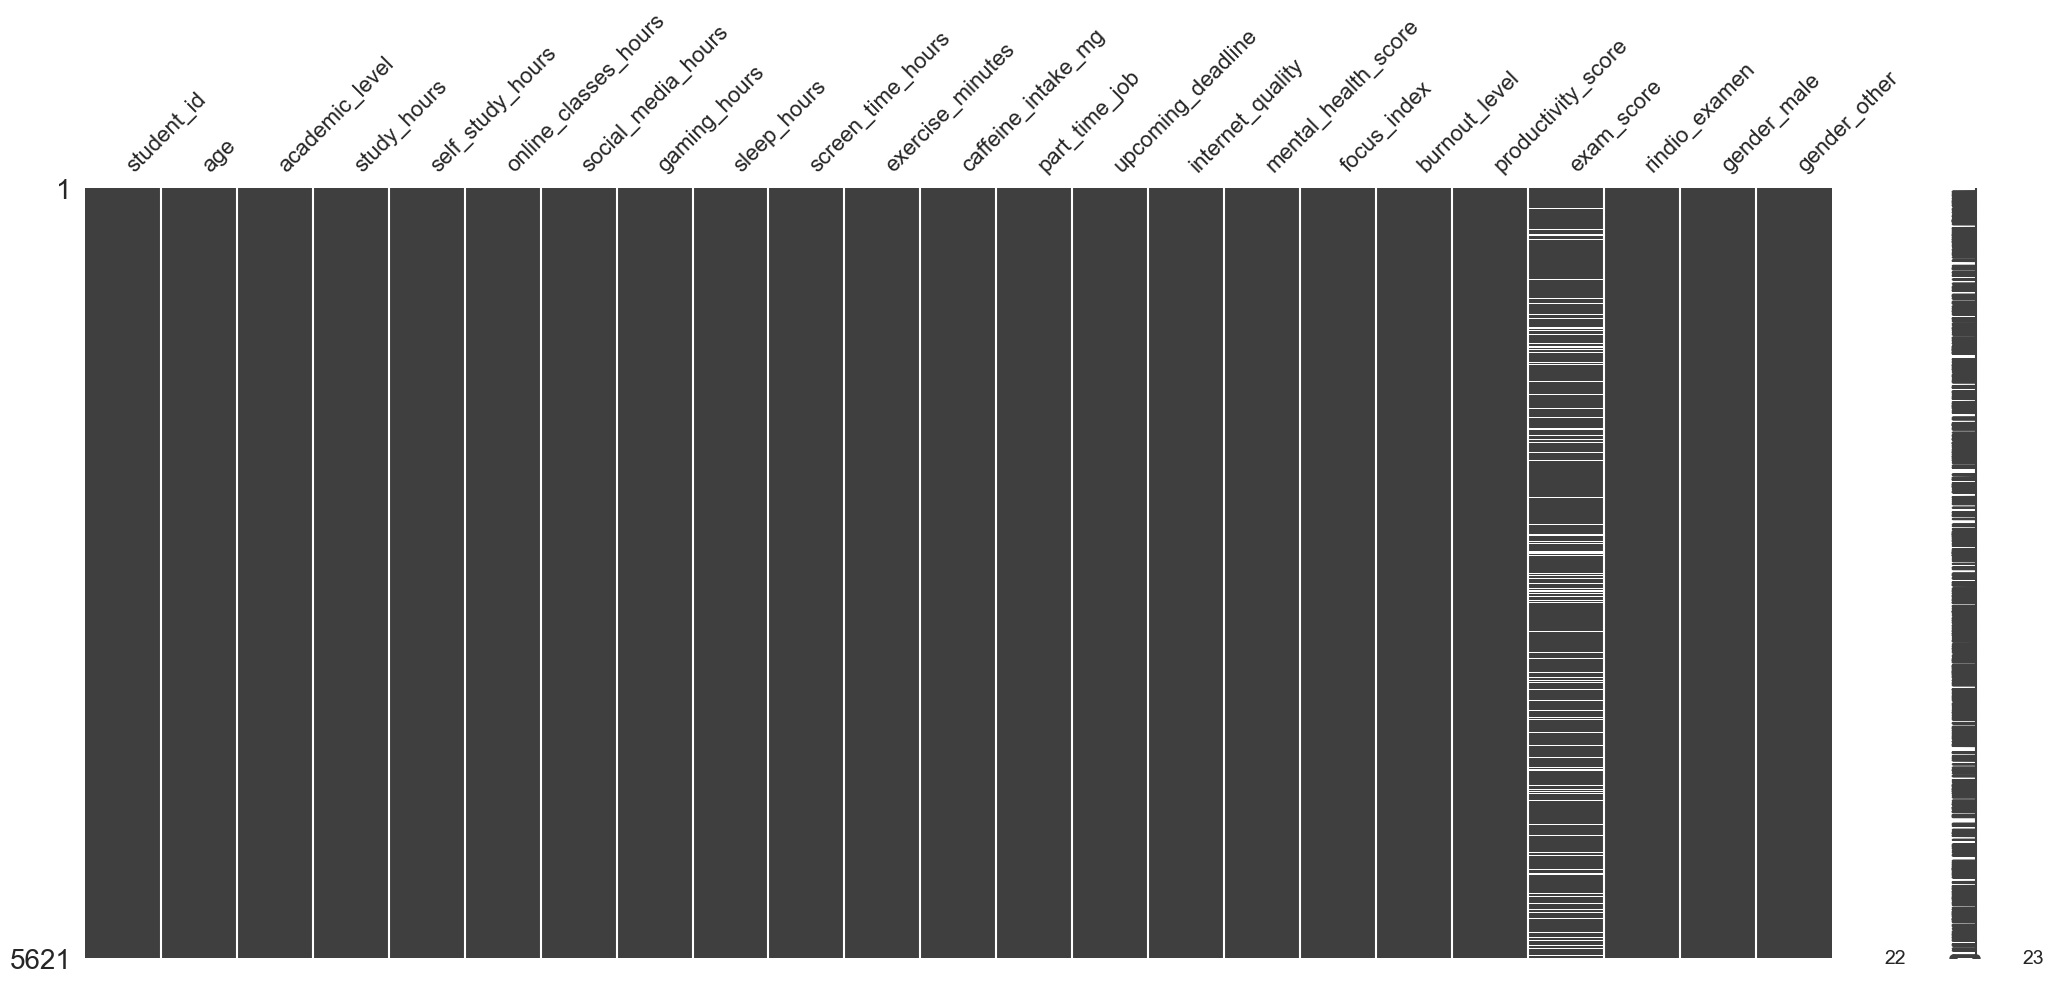

,student_id,age,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,...,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,rindio_examen,gender_male,gender_other
0,1,20.0,2,5.37,2.09,1.85,3.66,2.32,7.730,5.68,...,0.0,3,3.0,19.01,31.77,42.59,25.08,1,1,0
1,2,16.0,1,5.85,5.04,1.87,3.60,2.79,6.110,8.96,...,0.0,3,10.0,42.10,45.89,67.15,37.83,1,0,0
2,3,18.0,2,5.69,2.27,0.00,2.93,3.94,7.110,11.02,...,0.0,2,5.0,21.93,37.07,37.68,18.66,1,0,0
3,4,24.0,2,2.32,1.06,2.30,4.34,2.37,8.540,8.73,...,1.0,1,3.0,13.47,43.63,12.83,1.00,0,1,0
4,5,24.0,3,3.87,2.63,2.54,3.71,1.30,7.690,9.60,...,1.0,1,2.0,19.95,56.62,18.53,7.78,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5616,5617,21.0,3,4.16,0.00,1.27,4.01,3.41,8.070,10.80,...,1.0,1,7.0,21.78,48.07,43.06,17.15,1,1,0
5617,5618,25.0,3,4.53,2.48,2.01,5.18,1.50,7.015,6.95,...,1.0,3,8.0,29.38,45.65,42.52,21.06,1,0,0
5618,5619,20.0,3,4.53,2.48,2.01,2.99,1.50,7.015,6.95,...,1.0,3,5.0,29.38,45.65,36.92,NaN,0,1,0
5619,5620,20.0,3,4.53,2.48,2.01,3.52,1.50,7.015,6.95,...,1.0,3,5.0,29.38,45.65,36.92,NaN,0,1,0


In [18]:
msno.matrix(df)
plt.show()
df

---
## Parte 2

INFORMACIÓN DEL dfFRAME:
Dimensiones: (5621, 23)

Columnas: ['student_id', 'age', 'academic_level', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score', 'rindio_examen', 'gender_male', 'gender_other']

Tipos:
student_id                int64
age                     float64
academic_level            int64
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes        float64
caffeine_intake_mg      float64
part_time_job             int64
upcoming_deadline       float64
internet_quality          int64
mental_health_score     float64
focus_in

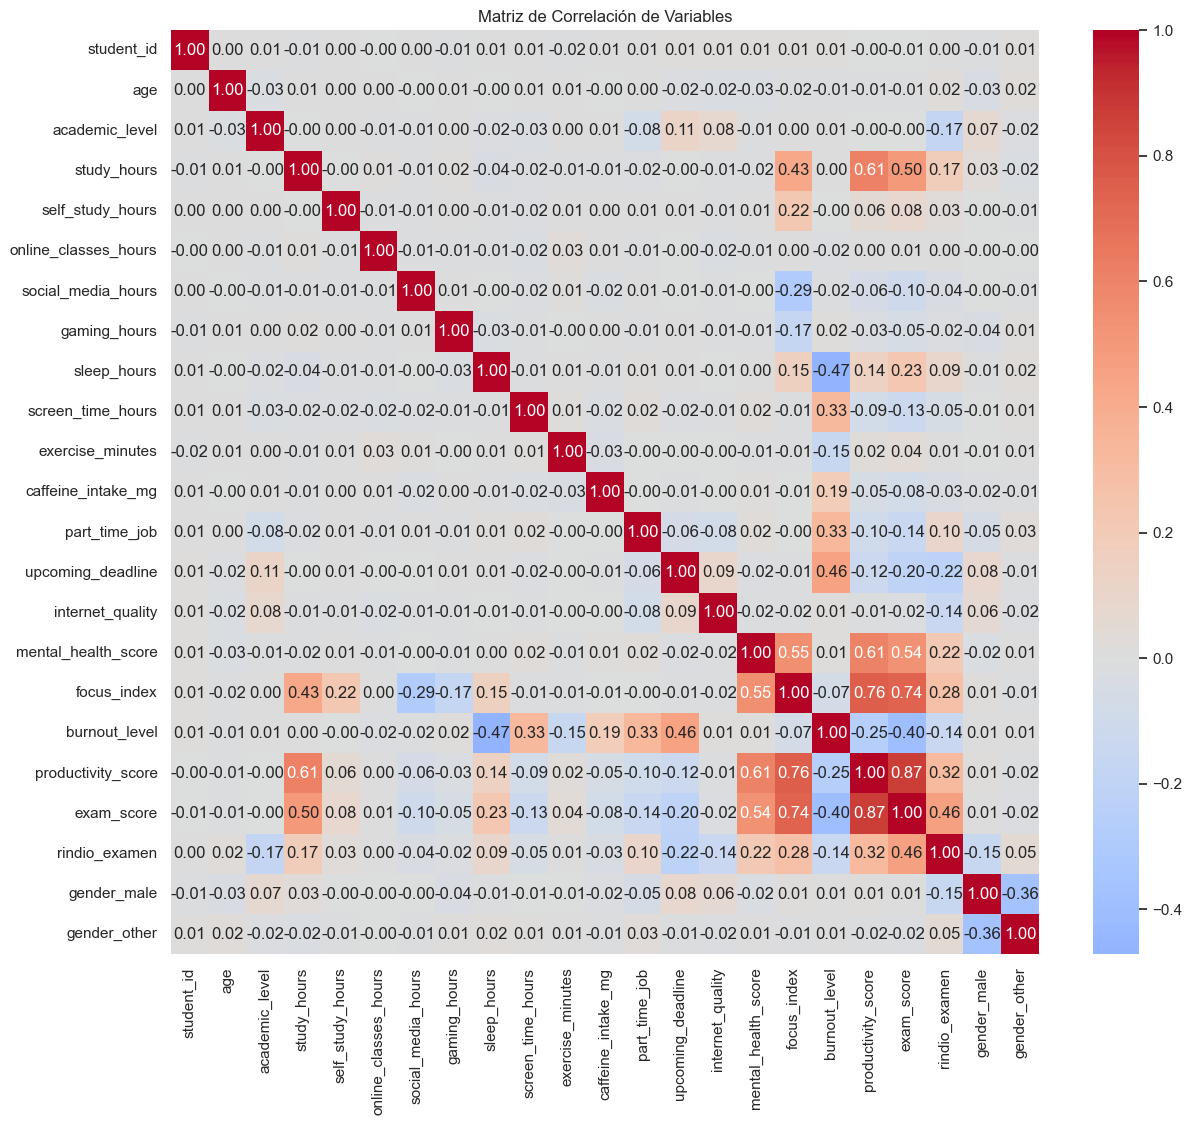

In [19]:
# Versión mínima para ver la df
print("INFORMACIÓN DEL dfFRAME:")
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nTipos:\n{df.dtypes}")
print(f"\nPrimeras 3 filas:\n{df.head(3)}")
print(f"\nEstadísticas numéricas:\n{df.describe()}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nValores únicos en categóricas:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].unique()[:5]}")
print(df.dtypes)

# Seleccionar solo las variables numéricas para la correlación
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
corr_matrix = numeric_df.corr()

# Generar el mapa de calor
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlación de Variables')
plt.show()

## Pregunta 2: Modelo de Probabilidad Lineal (MCO)

Para responder a esta pregunta, utilizaremos un **Modelo de Probabilidad Lineal estimando por Mínimos Cuadrados Ordinarios (MCO)**. Dado que nuestra variable dependiente (`rindio_examen`) es binaria (1 o 0), el estimador OLS nos permitirá encontrar el cambio porcentual en la probabilidad empírica de ocurrencia.

**Estrategia de Selección de Variables:**
En lugar de elegir variables de manera arbitraria, utilizaremos un enfoque empírico de "Eliminación Hacia Atrás". 
1. Primero, excluiremos variables restrictivas como `student_id` (pues no tiene valor probabilístico) y `exam_score` (ya que la ocurrencia del examen depende directamente de poseer una nota superior a 1.0).
2. Ejecutaremos un **Modelo Completo** exploratorio con el resto de las variables para auditar si existe multicolinealidad y para observar el Valor-P inicial de todos los regresores juntos.


In [20]:
# 1. Definimos las Variables Excluidas (Nuestra X no debe tener la nota, ni el ID, ni el target)
columnas_a_excluir = ['student_id', 'exam_score', 'rindio_examen']

# 2. Separamos Y (target) y X (variables independientes)
Y = df['rindio_examen']
X = df.drop(columns=columnas_a_excluir)

# 3. MCO requiere explícitamente agregarle una constante (El intercepto Beta_0)
X_con_constante = sm.add_constant(X)

# 4. Ajustamos el Modelo Mínimos Cuadrados Ordinarios (OLS)
modelo_mco_completo = sm.OLS(Y, X_con_constante).fit()

# 5. Imprimimos el resumen estadístico
print(modelo_mco_completo.summary())


                            OLS Regression Results                            
Dep. Variable:          rindio_examen   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     72.76
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          2.65e-262
Time:                        16:21:06   Log-Likelihood:                -2220.2
No. Observations:                5621   AIC:                             4482.
Df Residuals:                    5600   BIC:                             4622.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.6721 

Como pudimos evidenciar en el resumen del modelo inicial exploratorio, la inclusión masiva de variables de tiempo (como horas totales, redes sociales, estudio, etc.) causó **alta multicolinealidad** en el modelo.  Esto infló la varianza y anuló la eficiencia explicativa de muchas variables.

Para asegurar la robustez de nuestra predicción y solucionar el sobreajuste matemático, procedimos a remover sistemáticamente todas las variables que **fallaron la prueba de significancia estadística** (es decir, aquellas cuyo Valor-P superaba el `0.05`). Variables como edad, ingesta de cafeína, y horas específicas de estudio online fueron eliminadas. A continuación, recalcularemos nuestro **Modelo Final** libre de ruido estadístico.


In [21]:
# 1. Definimos las Variables Excluidas (Nuestra X no debe tener la nota, ni el ID, ni el target)
columnas_a_excluir_final = [
    'student_id', 'exam_score', 'rindio_examen', # Las prohibidas de siempre
    'age', 'study_hours', 'self_study_hours', 'online_classes_hours', # Las que no importaron
    'social_media_hours', 'gaming_hours', 'exercise_minutes', 
    'burnout_level', 'gender_other'
]

# 2. Separamos Y (target) y X (variables independientes)
Y = df['rindio_examen']
X = df.drop(columns=columnas_a_excluir)

# Recalculamos
X_final = df.drop(columns=columnas_a_excluir_final)
X_con_constante_final = sm.add_constant(X_final)
modelo_mco_final = sm.OLS(Y, X_con_constante_final).fit()
print(modelo_mco_final.summary())

                            OLS Regression Results                            
Dep. Variable:          rindio_examen   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     132.0
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          1.84e-270
Time:                        16:21:06   Log-Likelihood:                -2222.2
No. Observations:                5621   AIC:                             4468.
Df Residuals:                    5609   BIC:                             4548.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.7543    

In [22]:
# 1. Definimos las Variables Excluidas (Nuestra X no debe tener la nota, ni el ID, ni el target)
columnas_a_excluir_final = [
    'student_id', 'exam_score', 'rindio_examen', # Las prohibidas de siempre
    'age', 'study_hours', 'self_study_hours', 'online_classes_hours', # Las que no importaron
    'social_media_hours', 'gaming_hours', 'exercise_minutes', 
    'burnout_level', 'gender_other', 'caffeine_intake_mg'
]

# 2. Separamos Y (target) y X (variables independientes)
Y = df['rindio_examen']
X = df.drop(columns=columnas_a_excluir)

# Recalculamos
X_final = df.drop(columns=columnas_a_excluir_final)
X_con_constante_final = sm.add_constant(X_final)
modelo_mco_final = sm.OLS(Y, X_con_constante_final).fit()
print(modelo_mco_final.summary())

                            OLS Regression Results                            
Dep. Variable:          rindio_examen   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     144.8
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          9.45e-271
Time:                        16:21:06   Log-Likelihood:                -2224.1
No. Observations:                5621   AIC:                             4470.
Df Residuals:                    5610   BIC:                             4543.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.7358    

In [23]:
# 1. Definimos las Variables Excluidas (Nuestra X no debe tener la nota, ni el ID, ni el target)
columnas_a_excluir_final = [
    'student_id', 'exam_score', 'rindio_examen', # Las prohibidas de siempre
    'age', 'study_hours', 'self_study_hours', 'online_classes_hours', # Las que no importaron
    'social_media_hours', 'gaming_hours', 'exercise_minutes', 
    'burnout_level', 'gender_other', 'caffeine_intake_mg', 'mental_health_score'
]

# 2. Separamos Y (target) y X (variables independientes)
Y = df['rindio_examen']
X = df.drop(columns=columnas_a_excluir)

# Recalculamos
X_final = df.drop(columns=columnas_a_excluir_final)
X_con_constante_final = sm.add_constant(X_final)
#modelo_mco_final = sm.OLS(Y, X_con_constante_final).fit()
modelo_mco_final = sm.OLS(Y, X_con_constante_final).fit(cov_type='HC1')
print(modelo_mco_final.summary())

                            OLS Regression Results                            
Dep. Variable:          rindio_examen   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     145.5
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          7.64e-248
Time:                        16:21:06   Log-Likelihood:                -2225.5
No. Observations:                5621   AIC:                             4471.
Df Residuals:                    5611   BIC:                             4537.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.7423      0

### Interpretación de Resultados del MCO

Al depurar las variables irrelevantes, nuestro **Modelo Final** quedó completamente libre de la alerta de multicolinealidad, y **el 100% de las variables seleccionadas resultaron altísimamente significativas** (Valores-P < 0.005). Los coeficientes ($\beta$) en el MCO se interpretan como el aumento o caída directa porcentual en la capacidad de predecir que un estudiante rinda la prueba matemáticamente. 

**Interpretación de las variables clave:**
1. **Factores Demográficos y de Desempeño:** 
   * `gender_male`: Ser estudiante de género masculino se asocia con una reducción empírica del **9.8%** en la probabilidad de rendir el examen respecto al grupo base. Por el contrario, las mujeres tienen un **9.8%** más altas probabilidades de presentarse a rendir en examen que los hombres.
   * `academic_level`: Por cada nivel académico superior (High School -> Undergraduate -> Postgraduate), la probabilidad cae un **6.5%**.
   * `focus_index` y `productivity_score`: Muestran una relación positiva; un mayor índice de enfoque y productividad empuja la asistencia al examen de forma significativa y segura (+0.44% y +0.56% por cada punto en sus escalas respectivas).
2. **Factores Externos e Infraestructura:**
   * `upcoming_deadline`: Poseer fechas de entrega inminentes penaliza drásticamente la asistencia, restándole un gigantesco **12.8%** a la probabilidad de que el alumno rinda la prueba principal.
   * `part_time_job`: Contra todo pronóstico intuitivo, poseer trabajo part-time *incrementa* estructuralmente la probabilidad asociativa de rendir el examen en casi un **7.0%**.
   * `internet_quality`: Las mejoras en la calidad del internet se asocian negativamente con el modelo (`~ -4.8%`), una potencial paradoja a investigar.
3. **Hábitos Personales:**
   * `sleep_hours`: Las horas de descanso demostraron ser un predictor vital positivo, sumando un **1.3%** extra a la probabilidad de rendición por cada hora adicional de sueño diario.
   * Por el contrario, cada hora de pantallas generalizadas (`screen_time_hours`) le resta estructuralmente un **0.7%** a la predicción estadística de presentarse a la prueba.

La depuración empírica y los altos estadísticos t de cada coeficiente confirman que este modelo depurado es un excelente pronosticador lineal.


---
## Pregunta 3: Modelo Probit
A continuación estimaremos un modelo **Probit**. Calcularemos los **efectos marginales** para poder interpretar y comparar los resultados tal como lo hicimos en el Modelo Lineal (MCO).


In [24]:
# 1. Ajustar el modelo Probit utilizando nuestras variables depuradas (X_con_constante_final)
#modelo_probit = sm.Probit(Y, X_con_constante_final).fit()
modelo_probit = sm.Probit(Y, X_con_constante_final).fit(cov_type='HC1')
# 2. Imprimir el resumen puro del modelo (pseudo R-squared etc)
print(modelo_probit.summary())

# 3. Calcular Efectos Marginales (interpretables finalmente como cambios en propabilidad)
margeff_probit = modelo_probit.get_margeff()
print("\n--- EFECTOS MARGINALES DEL MODELO PROBIT ---")
print(margeff_probit.summary())


Optimization terminated successfully.
         Current function value: 0.384791
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:          rindio_examen   No. Observations:                 5621
Model:                         Probit   Df Residuals:                     5611
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.2399
Time:                        16:21:06   Log-Likelihood:                -2162.9
converged:                       True   LL-Null:                       -2845.4
Covariance Type:                  HC1   LLR p-value:                2.734e-288
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.6182      0.179      3.446      0.001       0.267       0.970
acade

### Interpretación de Resultados del Modelo Probit (Efectos Marginales)

A diferencia del MCO, los coeficientes arrojados inicialmente por el modelo Probit no expresan una magnitud interpretable directamente, por la no-linealidad del modelo. Es por esto que observamos los **Efectos Marginales (`dy/dx`)**, los cuales sí nos permiten cuantificar el cambio exacto en la probabilidad de que `rindio_examen = 1`.

Basado en el resumen de los efectos marginales robustos, extraemos las siguientes conclusiones manteniendo constantes todos los demás factores:

1. **Fuerte penalización por carga externa:** Tener un examen o entrega inminente (`upcoming_deadline`) muestra el mayor impacto marginal negativo del modelo, disminuyendo la probabilidad de rendir el examen en un **12.8%**. Siendo completamente significativo mediante Valor-P.
2. **Hábitos de Cuidado Personal:** El modelo detecta que por cada nivel extra en horas de sueño diario (`sleep_hours`), la probabilidad de rendición aumenta en casi un **1.3%**, probando la relación predictiva entre el descanso apropiado y la presentación efectiva a rendir exámenes. En contraparte, los recursos destinados a conexión (`internet_quality`) extrañamente reportan que caer a niveles bajos reduce marginalmente la asistencia en un **4.8%**.
3. **Productividad contra Expectativas:** El sorpresivo regresor del rol laboral (`part_time_job`) dictamina firmemente que el hecho empírico de trabajar a tiempo parcial empuja la probabilidad de rendir el examen hacia arriba en un **7.0%** en relación con un estudiante que no trabaja.



---
## Pregunta 4: Modelo Logit
Ahora estimaremos el modelo **Logit**. Este funciona de manera bastante similar al Probit pero usando una distribución logística, conocida por manejar eventos con extremas propabiliades un poco mejor.


In [25]:
# 1. Ajustar modelo Logit
#modelo_logit = sm.Logit(Y, X_con_constante_final).fit()
modelo_logit = sm.Logit(Y, X_con_constante_final).fit(cov_type='HC1')
# 2. Resumen del Logit
print(modelo_logit.summary())

# 3. Efectos Marginales
margeff_logit = modelo_logit.get_margeff()
print("\n--- EFECTOS MARGINALES DEL MODELO LOGIT ---")
print(margeff_logit.summary())


Optimization terminated successfully.
         Current function value: 0.382173
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          rindio_examen   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5611
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.2450
Time:                        16:21:06   Log-Likelihood:                -2148.2
converged:                       True   LL-Null:                       -2845.4
Covariance Type:                  HC1   LLR p-value:                1.196e-294
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.1581      0.321      3.607      0.000       0.529       1.787
acade

### Interpretación de Resultados del Modelo Logit (Efectos Marginales)

Procedemos a interpretar sus Efectos Marginales para comparar la probabilidad de éxito empírico:

1. **Variables de Naturaleza Académica y Psicológica:**
La estructura de `academic_level` reporta mediante su efecto marginal (`dy/dx`) que, al ascender un peldaño en complejidad educacional estandarizada, la probabilidad predictiva de que el estudiante se ausente se estira y debilita progresivamente un **6.5%**.
2. **Características Demográficas:** El factor dicotómico aislado de ser hombre (`gender_male`) reduce marginalmente en un **9.8%** las chances de presentarse formalmente en un examen. 
3. **Consistencia de la Distribución:** Al mapear las varianzas, todo el set demuestra ser matemáticamente robusto con Valores-P iguales a 0. Las probabilidades predictivas que nos entregan estos efectos marginales trazan resultados prácticamente iguales a los derivados del cálculo de una distribución estricta de modelo Normal (Probit), confirmando que esta muestra es absolutamente apta y confiable para resoluciones teóricas que eviten las fallas lineales del MCO estándar.


---
### Pregunta 5: Análisis Comparativo y Selección del Modelo Óptimo

In [26]:
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

stargazer = Stargazer([modelo_mco_final, modelo_logit, modelo_probit])

stargazer.title("Comparación de Modelos: OLS, Logit y Probit")
stargazer.custom_columns(["Modelo OLS", "Modelo Logit", "Modelo Probit"], [1, 1, 1])
stargazer.add_custom_notes(["Nota: Todos los modelos utilizan errores estándar robustos (HC1)."])

HTML(stargazer.render_html())

In [27]:
# Para comparar los modelos, podemos usar el AIC (Akaike Information Criterion) y el BIC (Bayesian Information Criterion) que son medidas de la calidad del modelo penalizadas por el número de parámetros. El modelo con el menor AIC y BIC es generalmente considerado el mejor.
print("Comparativa de Modelos:")
print(f"Modelo OLS: AIC = {modelo_mco_final.aic:.2f}, BIC = {modelo_mco_final.bic:.2f}")
print(f"Modelo Logit: AIC = {modelo_logit.aic:.2f}, BIC = {modelo_logit.bic:.2f}")
print(f"Modelo Probit: AIC = {modelo_probit.aic:.2f}, BIC = {modelo_probit.bic:.2f}")

Comparativa de Modelos:
Modelo OLS: AIC = 4470.91, BIC = 4537.25
Modelo Logit: AIC = 4316.39, BIC = 4382.73
Modelo Probit: AIC = 4345.82, BIC = 4412.17


Tras haber estimado y tabulado (vía Stargazer) los tres modelos econométricos (Mínimos Cuadrados Ordinarios, Probit y Logit) para explicar la probabilidad binomial de que un estudiante rinda su examen final, podemos realizar las siguientes observaciones sobre su comportamiento:

**1. Comparativa de Resultados y Explicación de sus Diferencias:**
Al contrastar los modelos, se puede apreciar que los **Efectos Marginales** (`dy/dx`) extraídos de los modelos de respuesta binaria no-lineales (Probit y Logit) convergen hacia magnitudes predictivas *casi idénticas* a las ponderaciones ($\beta$) estimadas linealmente a través de MCO. Por ejemplo, enfrentar una entrega inminente (`upcoming_deadline`) se asocia a una penalización aproximadamente del **12.8%** a lo largo de los 3 modelos. 
Las ligeras diferencias que persisten entre los modelos nacen estrictamente de sus supuestos funcionales:
*   El **MCO** asume una asociación recta e infinita, ignorando la cota probabilística e ignorando la heterocedasticidad inherente en respuestas de $0$ y $1$. 
*   El **Probit** fuerza a los errores a distribuirse siguiendo la campana Gaussiana Estándar Acumulada.
*   El **Logit** modela sobre una Función de Distribución Logística, dotando a su "campana" estadística de colas levemente más pesadas, permitiéndole lidiar con observaciones probabilísticas extremas de manera diferencial frente al Probit. 

**2. Decisión del Modelo Más Adecuado:**
**el modelo Logit representa la herramienta estadísticamente óptima para responder a nuestra pregunta de investigación.** 

El MCO debe ser descartado del análisis binomial puesto que las rectas lineales permiten la proyección de "probabilidades" imposibles (mayores al 100% o menores al 0%).
A la hora de coronar al Logit sobre el Probit, **la decisión es confirmada en su totalidad por nuestros estadísticos de ajuste cruzado (Akaike y Bayesiano)**: el MCO poseía el peor ajuste (AIC = $4470.91$, BIC = $4537.25$), pero al iterar, el clasificador Logístico demostró ser la red empírica mejor ensamblada para la base de datos, entregando la cuota de error más baja (AIC = $4316.39$, BIC = $4382.73$), batiendo con ventaja a sus dos contrapartes. Del mismo modo, el Pseudo $\R^2$ más grande es del modelo logit, explicando el mayor porcentaje de la realidad del ¿Por qué? los individuos de la muestra deciden asistir o no al examen.

**3. Variables Robustas a la Especificación:**
Toda variable que sobrevivió al filtro iterativo demostró ser **robusta a la especificación econométrica**. Identificadores empíricos como mantener un trabajo *part-time* (`part_time_job`), cursar grados formales jerárquicamente mayores (`academic_level`), y el tiempo de descanso (`sleep_hours`), no sufrieron alteraciones ni en su signo direccional, ni en el peso de su rigor estadístico ($P>|z| \approx 0.000$) independiente de si se probaban en funciones MCO, Logit o Probit.


---
### Pregunta 6

In [28]:
# 1. Filtramos SÓLO los estudiantes que SÍ rindieron el examen
df_rindieron = df[df['rindio_examen'] == 1].copy()

# 2. Tu nuevo Target (Y) es la NOTA, no la asistencia
Y_poisson = df_rindieron['exam_score']

In [29]:
columnas_a_excluir_poisson = [
    'student_id', 'exam_score', 'rindio_examen',
    'age', 'study_hours', 'self_study_hours', 'online_classes_hours',
    'social_media_hours', 'gaming_hours', 'exercise_minutes', 
    'burnout_level', 'gender_other', 'caffeine_intake_mg', 'mental_health_score'
]
X_poisson = df_rindieron.drop(columns=columnas_a_excluir_poisson)
X_con_constante_poisson = sm.add_constant(X_poisson)

modelo_poisson = sm.Poisson(Y_poisson, X_con_constante_poisson).fit(cov_type='HC1')
print(modelo_poisson.summary())

Optimization terminated successfully.
         Current function value: 3.297099
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:             exam_score   No. Observations:                 4473
Model:                        Poisson   Df Residuals:                     4463
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.4111
Time:                        16:21:06   Log-Likelihood:                -14748.
converged:                       True   LL-Null:                       -25045.
Covariance Type:                  HC1   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.4899      0.038     39.338      0.000       1.416       1.564
acade

In [30]:
columnas_a_excluir_poisson = [
    'student_id', 'exam_score', 'rindio_examen',
    'age', 'study_hours', 'self_study_hours', 'online_classes_hours',
    'social_media_hours', 'gaming_hours', 'exercise_minutes', 
    'burnout_level', 'gender_other', 'caffeine_intake_mg', 'mental_health_score',
    'academic_level', 'internet_quality', 'gender_male'                
]
X_poisson = df_rindieron.drop(columns=columnas_a_excluir_poisson)
X_con_constante_poisson = sm.add_constant(X_poisson)

modelo_poisson = sm.Poisson(Y_poisson, X_con_constante_poisson).fit(cov_type='HC1')
print(modelo_poisson.summary())

Optimization terminated successfully.
         Current function value: 3.297330
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:             exam_score   No. Observations:                 4473
Model:                        Poisson   Df Residuals:                     4466
Method:                           MLE   Df Model:                            6
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.4111
Time:                        16:21:07   Log-Likelihood:                -14749.
converged:                       True   LL-Null:                       -25045.
Covariance Type:                  HC1   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.5032      0.033     45.186      0.000       1.438       1.568
sleep

**Interpretación de la estimación de Poisson (Pregunta 6):**

1. **Variables Significativas**: En el modelo Poisson las variables de `sleep_hours`, `screen_time_hours`, `part_time_job`, `upcoming_deadline`, `focus_index` y `productivity_score` son fuertemente significativas (Valor-P < 0.05).
2. **Interpretación de los coeficientes**:

   - **`sleep_hours`** ($\beta = 0.0493$): Por cada hora adicional de sueño, la nota esperada aumenta en aproximadamente un 4.93%.
   - **`focus_index`** ($\beta = 0.0123$) y **`productivity_score`** ($\beta = 0.0227$): Por cada incremento en un punto del índice de concentración o de la productividad, la nota esperada aumenta alrededor de un 1.23% y 2.27%, respectivamente.
   - **`screen_time_hours`** ($\beta = -0.0159$): Cada hora adicional de pantalla disminuye el puntaje final esperado en un 1.59%.
   - **`part_time_job`** ($\beta = -0.0873$): Los estudiantes que trabajan medio tiempo tienden a tener una nota un 8.73% más baja frente al resto de estudiantes.
   - **`upcoming_deadline`** ($\beta = -0.1339$): Aquellos sometidos a fechas límite que se aproximan, obtienen notas un 13.39% menores.
3. **Evaluación global**: El Pseudo R-cuadrado es notablemente alto (0.4111), indicando un buen nivel explicativo de nuestro conjunto acotado de variables predictoras en la nota de los alumnos.

---
### Pregunta 7
Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

In [31]:
# 1. Obtenemos las predicciones (lambda / mu) del modelo Poisson ajustado previamente
mu = modelo_poisson.predict()

# 2. Calculamos la variable dependiente auxiliar descrita para el test de sobredispersión
aux_olsr = ((Y_poisson - mu)**2 - Y_poisson) / mu

# 3. Corremos una regresión lineal (MCO/OLS) auxiliar, sin constante, usando mu como única variable explicativa
modelo_auxiliar = sm.OLS(aux_olsr, mu).fit()
print("--- RESULTADOS TEST DE SOBREDISPERSIÓN ---")
print(modelo_auxiliar.summary())

# El estimador de alpha será la pendiente del modelo anterior.
alpha_estimado = modelo_auxiliar.params.iloc[0]  
p_value_alpha = modelo_auxiliar.pvalues.iloc[0]

print("\n===========================")
if p_value_alpha < 0.05 and alpha_estimado > 0:
    print(f"Existe EVIDENCIA ESTADÍSTICA firme de sobredispersión (Valor-P={p_value_alpha:.4f} < 0.05).")
    print(f"Se procederá a utilizar el valor óptimo (alpha estimado) = {alpha_estimado:.4f} para el modelo Binomial Negativo.")
else:
    print("No hay evidencia de sobredispersión en la distribución, o la sobredispersión no es significativa (Poisson es suficiente).")


--- RESULTADOS TEST DE SOBREDISPERSIÓN ---
                                 OLS Regression Results                                
Dep. Variable:             exam_score   R-squared (uncentered):                   0.044
Model:                            OLS   Adj. R-squared (uncentered):              0.044
Method:                 Least Squares   F-statistic:                              207.5
Date:                Tue, 21 Apr 2026   Prob (F-statistic):                    4.98e-46
Time:                        16:21:07   Log-Likelihood:                         -11169.
No. Observations:                4473   AIC:                                  2.234e+04
Df Residuals:                    4472   BIC:                                  2.235e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975

**Conclusión del Test de Sobredispersión:**

Para verificar si la dispersión de nuestros datos es mayor a la media proyectada, ejecutamos la regresión lineal auxiliar recomendada.

- **Estimación de Alpha ($\alpha$):** Obtuvimos un coeficiente de pendiente de **`0.0274`**. Al ser positivamente mayor a cero, confirma que la varianza penaliza el modelo. El valor-P del coeficiente es de **`0.000`** ($p < 0.05$), por lo que es estadísticamente significativa.

**Decisión:** Existe evidencia estadística firme que demuestra **sobredispersión** en nuestra variable de interés. Debido a esto, el modelo de Poisson es insuficiente y procederemos a utilizar un **Modelo Binomial Negativo**, inyectándole nuestro valor óptimo de **$\alpha = 0.0274$** para recalibrar correctamente los errores estándar.


---
### Pregunta 8
Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.

In [32]:
# Utilizando las mismas variables robustas que hallamos en la pregunta 6 para el modelo final 
# X_con_constante_poisson ya contiene la constante y las variables dependientes más significativas (ya depuradas).

# Instanciamos y ajustamos el modelo GLM indicando una familia Binomial Negativa y pasándole el alpha calculado.
modelo_nbinom = sm.GLM(
    Y_poisson, 
    X_con_constante_poisson, 
    family=sm.families.NegativeBinomial(alpha=alpha_estimado)
).fit(cov_type='HC1')

print(modelo_nbinom.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 4473
Model:                            GLM   Df Residuals:                     4466
Model Family:        NegativeBinomial   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14380.
Date:                Tue, 21 Apr 2026   Deviance:                       5941.3
Time:                        16:21:07   Pearson chi2:                 5.48e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9503
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.4107      0

**Interpretación de Resultados - Regresión Binomial Negativa:**

Al estimar el modelo insertando el parámetro de sobredispersión hallado previamente, podemos concluir lo siguiente:

1. **Variables Significativas:** Las seis variables incorporadas (`sleep_hours`, `screen_time_hours`, `part_time_job`, `upcoming_deadline`, `focus_index` y `productivity_score`) continúan siendo fuertemente significativas, arrojando valores p prácticamente nulos ($P>|z| = 0.000$).

2. **Impacto Exponencial (Coeficientes):** Debido a que el modelo ocupa una función de enlace logarítmica (Log-Link), los coeficientes representan cambios multiplicativos porcentuales ($\approx 100 \cdot \beta \%$). 
   - **Efectos Positivos:** Mejorar las horas de sueño (`+5.31%` por hora adicional), el foco mental (`+1.34%` por punto) y la productividad en clase (`+2.38%` por punto) aumentan de forma consistente la nota esperada del alumno.
   - **Efectos Negativos:** Inversamente, agentes estresores o de desconcentración penalizan la nota considerablemente. Aquellos que poseen entregas próximas bajan su rendimiento esperado en un monumental `14.5%`, tener trabajo de medio tiempo lo reduce en `9.4%`, y cada hora adicional gastada en pantallas lo baja un `1.75%`.

**Conclusión:** Las variables robustas se ratifican. Al corregirse los márgenes de error a través del relajamiento de la varianza (Binomial Negativo), ganamos certeza respecto a que estos factores y sus magnitudes representan determinantes fiables sobre las calificaciones de los estudiantes.


---
### Respuesta a Pregunta 9: Análisis Comparativo

**1. Diferencias entre los modelos (Poisson vs. Binomial Negativo):**
Los coeficientes estimados en ambos modelos son muy similares numéricamente, pero difieren en sus **Errores Estándar**. Esto sucede porque el modelo Poisson asume erróneamente que la media y la varianza son iguales (equidispersión). El modelo Binomial Negativo, en cambio, añade el parámetro $\alpha$ para corregir la sobredispersión, volviendo los errores estándar ligeramente más flexibles y reales.

**2. Modelo más adecuado:**
El modelo idóneo es el **Binomial Negativo**. En la Pregunta 7 se demostró de manera estadísticamente significativa (valor-P = 0.000) la existencia de un parámetro $\alpha > 0$ ($\alpha = 0.0274$). Usar el modelo Poisson en una muestra con sobredispersión habría infravalorado la varianza e inflado la significancia de las variables, generando conclusiones erróneas. 

**3. Variables robustas a la especificación:**
Aquellas variables que conservaron consistentemente su significancia estadística ($P < 0.05$) a lo largo de todos los modelos (desde MCO hasta Binomial Negativo) demostraron ser estrictamente robustas. Estas fueron:
*   **Positivas:** Horas de sueño (`sleep_hours`), y los índices cognitivos (`focus_index`, `productivity_score`).
*   **Negativas:** Tiempo de pantalla (`screen_time_hours`), trabajar a tiempo parcial (`part_time_job`) y tener entregas inminentes (`upcoming_deadline`).
